In [1]:
!pip install duckdb


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import duckdb

In [4]:
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Read json files
def read_yelp_json(filename: str) -> pd.DataFrame:
    """
    Read a Yelp Academic Dataset JSON file.

    Parameters
    ----------
    filename : str
        Example:
        'yelp_academic_dataset_review.json'

    Returns
    -------
    pd.DataFrame
    """
    # project root (one level above notebooks/)
    project_root = Path.cwd().parent

    file_path = project_root / "yelp_datasets" / "yelp_dataset" / filename

    return pd.read_json(file_path, lines=True)

In [7]:
#reviews = read_yelp_json("yelp_academic_dataset_review.json")
business = read_yelp_json("yelp_academic_dataset_business.json")
#users = read_yelp_json("yelp_academic_dataset_user.json")
tips = read_yelp_json("yelp_academic_dataset_tip.json")
checkins = read_yelp_json("yelp_academic_dataset_checkin.json")

In [8]:
business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.43,-119.71,5.00,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.55,-90.34,3.00,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Mailbox Centers, Printing Services","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', 'Wednesday': '8:0-18:30', 'Thursday': '8:0-18:30', 'Friday': '8:0-18:30', 'Saturday': '8:0-14:0'}"
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.22,-110.88,3.50,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCreditCards': 'True', 'RestaurantsPriceRange2': '2', 'CoatCheck': 'False', 'RestaurantsTakeOut': 'False', 'RestaurantsDelivery': 'False', 'Caters': 'False', 'WiFi': 'u'no'', 'BusinessParking': '{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}', 'WheelchairAccessible': 'True', 'HappyHour': 'False', 'OutdoorSeating': 'False', 'HasTV': 'False', 'RestaurantsReservations': 'False', 'DogsAllowed': 'False', 'ByAppointmentOnly': 'False'}","Department Stores, Shopping, Fashion, Home & Garden, Electronics, Furniture Stores","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', 'Wednesday': '8:0-22:0', 'Thursday': '8:0-22:0', 'Friday': '8:0-23:0', 'Saturday': '8:0-23:0', 'Sunday': '8:0-22:0'}"
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.96,-75.16,4.00,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeating': 'False', 'BusinessAcceptsCreditCards': 'False', 'BusinessParking': '{'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}', 'BikeParking': 'True', 'RestaurantsPriceRange2': '1', 'RestaurantsTakeOut': 'True', 'ByAppointmentOnly': 'False', 'WiFi': 'u'free'', 'Alcohol': 'u'none'', 'Caters': 'True'}","Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', 'Wednesday': '7:0-20:0', 'Thursday': '7:0-20:0', 'Friday': '7:0-21:0', 'Saturday': '7:0-21:0', 'Sunday': '7:0-21:0'}"
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.34,-75.47,4.50,13,1,"{'BusinessAcceptsCreditCards': 'True', 'WheelchairAccessible': 'True', 'RestaurantsTakeOut': 'True', 'BusinessParking': '{'garage': None, 'street': None, 'validated': None, 'lot': True, 'valet': False}', 'BikeParking': 'True', 'GoodForKids': 'True', 'Caters': 'False'}","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-22:0', 'Friday': '12:0-22:0', 'Saturday': '12:0-22:0', 'Sunday': '12:0-18:0'}"


In [9]:
tips.head()

,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban sandwiches,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


In [10]:
checkins.head()

,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020-07-24 22:42:27, 2020-10-24 21:36:13, 2020-12-09 21:23:33, 2021-01-20 17:34:57, 2021-04-30 21:02:03, 2021-05-25 21:16:54, 2021-08-06 21:08:08, 2021-10-02 15:15:42, 2021-11-11 16:23:50"
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011-07-18 22:30:31, 2012-09-07 20:28:50, 2013-03-27 15:57:36, 2013-08-13 00:31:34, 2013-08-13 00:31:48, 2013-09-23 17:39:38, 2013-11-18 06:34:08, 2014-04-12 23:04:47"
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012-03-11 10:30:02, 2012-04-24 07:07:59, 2012-04-24 07:43:31, 2013-05-25 16:41:10, 2014-05-02 15:49:55, 2014-09-18 02:28:23, 2014-11-10 15:16:43, 2015-09-27 13:18:32"
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014-09-30 14:41:47, 2014-10-23 18:22:28, 2015-04-27 19:55:00, 2015-09-21 12:52:09, 2015-10-01 12:46:16, 2015-10-22 13:35:04, 2016-01-14 12:27:43, 2016-02-01 15:15:07, 2016-02-11 12:22:47, 2016-03-31 23:15:46, 2016-04-11 13:11:34, 2016-05-25 12:44:11, 2016-06-27 15:46:11, 2016-06-30 15:14:28, 2016-07-28 14:15:59, 2016-09-22 20:05:06, 2016-11-16 19:00:11, 2016-12-27 14:36:14, 2017-01-24 20:18:16, 2017-02-21 16:01:49, 2017-03-21 14:08:44, 2017-05-21 16:07:21, 2017-08-07 14:17:39, 2021-06-21 19:59:50"


In [11]:
print(business.shape)
print(tips.shape)
print(checkins.shape)

(150346, 14)
(908915, 5)
(131930, 2)


In [12]:
business.business_id.nunique(), tips.business_id.nunique(), checkins.business_id.nunique()

(150346, 106193, 131930)

In [13]:
con = duckdb.connect()

reviews = con.execute("""
SELECT *
FROM read_json_auto('../yelp_datasets/yelp_dataset/yelp_academic_dataset_review.json')
""").fetchdf()

In [14]:
reviews.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.00,0,0,0,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. \n\nThe food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker.",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.00,1,0,1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.\n\nFor anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).\n\nThere is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class!",2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.00,0,0,0,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with no expectations. Next to the Clarion Hotel.",2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.00,1,0,1,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.00,1,0,1,"Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwich. Wasn't too much cheese which I liked. Needed something else...pepper jelly maybe. Would like to see more menu options added such as salads w fun cheeses. Lots of beer and wine as well as limited cocktails. Next time I will try one of the draft wines.",2017-01-14 20:54:15


In [15]:
reviews.date.min(), reviews.date.max()

(Timestamp('2005-02-16 03:23:22'), Timestamp('2022-01-19 19:48:45'))

In [16]:
reviews.shape

(6990280, 9)

In [17]:
users = con.execute("""
SELECT *
FROM read_json_auto('../yelp_datasets/yelp_dataset/yelp_academic_dataset_user.json')
LIMIT 2000000
""").fetchdf()

In [18]:
users.shape

(1987897, 22)

In [19]:
users.head()

user_id    name  review_count       yelping_since  useful  \
0  qVc8ODYU5SZjKXVBgXdI7w  Walker           585 2007-01-25 16:47:26    7217   
1  j14WgRoU_-2ZE1aw1dXrJg  Daniel          4333 2009-01-25 04:35:42   43091   
2  2WnXYQFK0hXEoTxPtV2zvg   Steph           665 2008-07-25 10:41:00    2086   
3  SZDeASXq7o05mMNLshsdIA    Gwen           224 2005-11-29 04:38:33     512   
4  hA5lMy-EnncsH4JoR-hFGQ   Karen            79 2007-01-05 19:40:59      29   

   funny   cool  \
0   1259   5994   
1  13066  27281   
2   1010   1003   
3    330    299   
4     15      7   

                                                               elite  \
0                                                               2007   
1  2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,20,20,2021   
2                                           2009,2010,2011,2012,2013   
3                                                     2009,2010,2011   
4                                                                      

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [20]:
users.columns

Index(['user_id', 'name', 'review_count', 'yelping_since', 'useful', 'funny',
       'cool', 'elite', 'friends', 'fans', 'average_stars', 'compliment_hot',
       'compliment_more', 'compliment_profile', 'compliment_cute',
       'compliment_list', 'compliment_note', 'compliment_plain',
       'compliment_cool', 'compliment_funny', 'compliment_writer',
       'compliment_photos'],
      dtype='object')

In [21]:
business.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

In [22]:
tips.columns

Index(['user_id', 'business_id', 'text', 'date', 'compliment_count'], dtype='object')

In [23]:
reviews.columns

Index(['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
       'cool', 'text', 'date'],
      dtype='object')

In [24]:
business.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

## Dataset Preperation

In [25]:
%%time
# ============================================================
# 1. Prepare datasets
# ============================================================

# Convert date columns to datetime
reviews["date"] = pd.to_datetime(reviews["date"])
tips["date"] = pd.to_datetime(tips["date"])
users["yelping_since"] = pd.to_datetime(users["yelping_since"])


# Rename columns to avoid ambiguity after merging
business_clean = business.rename(columns={
    "name": "business_name",
    "stars": "business_stars",
    "review_count": "business_review_count"
})

user_clean = users.rename(columns={
    "name": "user_name",
    "review_count": "user_review_count",
    "average_stars": "user_average_stars"
})

review_clean = reviews.rename(columns={
    "stars": "review_stars",
    "useful": "review_useful",
    "funny": "review_funny",
    "cool": "review_cool",
    "text": "review_text",
    "date": "review_date"
})

tip_clean = tips.rename(columns={
    "text": "tip_text",
    "date": "tip_date",
    "compliment_count": "tip_compliment_count"
})

CPU times: user 309 ms, sys: 2.55 s, total: 2.86 s
Wall time: 3.8 s


In [26]:
%%time

# ============================================================
# 2. Aggregate tip information for each business
# ============================================================

# A business may have multiple tips.
# Aggregate them into a single record that can be joined
# with each review.

tips_agg = (
    tip_clean
    .groupby("business_id")
    .agg(
        tip_count=("tip_text", "count"),
        sample_tips=("tip_text", lambda x: " | ".join(x.dropna().head(3))),
        avg_tip_compliment=("tip_compliment_count", "mean"),
        latest_tip_date=("tip_date", "max")
    )
    .reset_index()
)

CPU times: user 3.68 s, sys: 95 ms, total: 3.77 s
Wall time: 4 s


In [27]:
%%time
# ============================================================
# 3. Build the modeling dataset
# ============================================================

# Review table is used as the primary fact table.
# We enrich each review with:
#   - Business information
#   - User information
#   - Aggregated business tips

df = (
    review_clean

    # Business information
    .merge(
        business_clean[
            [
                "business_id",
                "business_name",
                "city",
                "state",
                "latitude",
                "longitude",
                "business_stars",
                "business_review_count",
                "is_open",
                "attributes",
                "categories"
            ]
        ],
        on="business_id",
        how="left"
    )

    # User information
    .merge(
        user_clean[
            [
                "user_id",
                "user_name",
                "user_review_count",
                "yelping_since",
                "user_average_stars",
                "useful",
                "funny",
                "cool",
                "fans",
                "elite"
            ]
        ],
        on="user_id",
        how="left",
        suffixes=("", "_user")
    )

    # Aggregated tips
    .merge(
        tips_agg,
        on="business_id",
        how="left"
    )
)

CPU times: user 9.08 s, sys: 14.1 s, total: 23.1 s
Wall time: 30 s


In [28]:
df.columns

Index(['review_id', 'user_id', 'business_id', 'review_stars', 'review_useful',
       'review_funny', 'review_cool', 'review_text', 'review_date',
       'business_name', 'city', 'state', 'latitude', 'longitude',
       'business_stars', 'business_review_count', 'is_open', 'attributes',
       'categories', 'user_name', 'user_review_count', 'yelping_since',
       'user_average_stars', 'useful', 'funny', 'cool', 'fans', 'elite',
       'tip_count', 'sample_tips', 'avg_tip_compliment', 'latest_tip_date'],
      dtype='object')

In [29]:
df.shape

(6990280, 32)

In [30]:
df.head()

,review_id,user_id,business_id,review_stars,review_useful,review_funny,review_cool,review_text,review_date,business_name,city,state,latitude,longitude,business_stars,business_review_count,is_open,attributes,categories,user_name,user_review_count,yelping_since,user_average_stars,useful,funny,cool,fans,elite,tip_count,sample_tips,avg_tip_compliment,latest_tip_date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.00,0,0,0,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. \n\nThe food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker.",2018-07-07 22:09:11,Turning Point of North Wales,North Wales,PA,40.21,-75.22,3.00,169,1,"{'NoiseLevel': 'u'average'', 'HasTV': 'False', 'RestaurantsAttire': ''casual'', 'BikeParking': 'False', 'Ambience': '{'touristy': False, 'hipster': False, 'romantic': False, 'divey': False, 'intimate': False, 'trendy': False, 'upscale': False, 'classy': False, 'casual': True}', 'WiFi': ''free'', 'DogsAllowed': 'False', 'Alcohol': ''none'', 'BusinessAcceptsCreditCards': 'True', 'RestaurantsGoodForGroups': 'True', 'RestaurantsPriceRange2': '2', 'RestaurantsReservations': 'False', 'WheelchairAccessible': 'True', 'BusinessAcceptsBitcoin': 'False', 'RestaurantsTableService': 'True', 'GoodForKids': 'True', 'Caters': 'False', 'HappyHour': 'False', 'RestaurantsDelivery': 'True', 'GoodForMeal': '{'dessert': False, 'latenight': False, 'lunch': True, 'dinner': False, 'brunch': True, 'breakfast': True}', 'OutdoorSeating': 'True', 'RestaurantsTakeOut': 'True', 'BusinessParking': '{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}'}","Restaurants, Breakfast & Brunch, Food, Juice Bars & Smoothies, American (New), Coffee & Tea, Sandwiches",Melanie,33.00,2016-01-13 17:20:44,4.06,32.00,3.00,8.00,0.00,,8.00,Food was fresh & well made. Service was good - we sat at the bar stools. | Get the fruit bruschetta! | Some of the worst service I ever had. Waited 20 minutes for someone to c,0.00,2021-12-23 01:44:27
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.00,1,0,1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.\n\nFor anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).\n\nThere is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class!",2012-01-03 15:28:18,Body Cycle Spinning Studio,Philadelphia,PA,39.95,-75.17,5.00,144,0,"{'BusinessAcceptsCreditCards': 'True', 'GoodForKids': 'False', 'ByAppointmentOnly': 'False', 'BusinessParking': '{'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}', 'BikeParking': 'True'}","Active Life, Cycling Classes, Trainers, Gyms, Fitness & Instruction",Erin,10.00,2011-03-07 19:45:15,4.30,6.00,1.00,2.00,0.00,,15.00,nina's class!! | Russel is awesome ! | 90 min spin,0.00,2017-06-13 01:37:13
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.00,0,0,0,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeñ

In [31]:

# Method for reducing the memory usage
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [32]:
df = reduce_mem_usage(df)

Mem. usage decreased to 1059.97 Mb (37.9% reduction)


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6990280 entries, 0 to 6990279
Data columns (total 32 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   review_id              object        
 1   user_id                object        
 2   business_id            object        
 3   review_stars           float16       
 4   review_useful          int16         
 5   review_funny           int16         
 6   review_cool            int16         
 7   review_text            object        
 8   review_date            datetime64[us]
 9   business_name          object        
 10  city                   object        
 11  state                  object        
 12  latitude               float16       
 13  longitude              float16       
 14  business_stars         float16       
 15  business_review_count  int16         
 16  is_open                int8          
 17  attributes             object        
 18  categories            

In [34]:
df.describe()

,review_stars,review_useful,review_funny,review_cool,review_date,latitude,longitude,business_stars,business_review_count,is_open,user_review_count,yelping_since,user_average_stars,useful,funny,cool,fans,tip_count,avg_tip_compliment,latest_tip_date
count,"6,990,280.00","6,990,280.00","6,990,280.00","6,990,280.00",6990280,"6,990,280.00","6,990,280.00","6,990,280.00","6,990,280.00","6,990,280.00","6,990,247.00",6990247,"6,990,247.00","6,990,247.00","6,990,247.00","6,990,247.00","6,990,247.00","6,497,836.00","6,497,836.00",6497836
mean,NaN,1.18,0.33,0.50,2017-01-11 11:22:33.441782,NaN,NaN,NaN,369.17,0.83,NaN,2013-10-16 16:34:32.289783,NaN,427.99,176.10,290.07,NaN,NaN,NaN,2019-10-25 15:07:13.246049536
min,1.00,-1.00,-1.00,-1.00,2005-02-16 03:23:22,27.56,-120.12,1.00,5.00,0.00,0.00,2004-10-12 08:46:11,1.00,0.00,0.00,0.00,0.00,1.00,0.00,2009-04-27 11:27:02
25%,3.00,0.00,0.00,0.00,2015-01-25 04:53:50.250000,29.97,-90.31,3.50,43.00,1.00,7.00,2011-07-17 17:02:09,3.39,3.00,0.00,0.00,0.00,6.00,0.00,2018-08-11 01:34:52
50%,4.00,0.00,0.00,0.00,2017-06-03 01:26:07,38.59,-86.19,4.00,135.00,1.00,24.00,2013-09-02 15:25:51,3.88,19.00,3.00,4.00,0.00,19.00,0.00,2020-09-10 16:27:23
75%,5.00,1.00,0.00,0.00,2019-05-23 00:02:46.250000,39.94,-75.50,4.50,364.00,1.00,98.00,2015-11-24 23:23:32.500000,4.29,111.00,24.00,39.00,4.00,53.00,0.01,2021-09-03 00:58:09
max,5.00,"1,182.00",792.00,404.00,2022-01-19 19:48:45,53.69,-73.19,5.00,"7,568.00",1.00,"17,472.00",2022-01-19 17:15:47,5.00,"206,296.00","185,823.00","199,878.00","12,496.00","2,572.00",3.00,2022-01-19 20:38:55
std,0.00,3.25,1.69,2.17,NaN,0.00,0.00,0.00,736.08,0.38,0.00,NaN,0.00,"3,226.60","1,998.33","2,761.55",0.00,0.00,0.00,NaN


## Analyse

In [35]:
# ============================================================
# 1. Basic data quality overview
# ============================================================

print("Shape:", df.shape)
print("Unique reviews:", df["review_id"].nunique())
print("Unique users:", df["user_id"].nunique())
print("Unique businesses:", df["business_id"].nunique())

missing_values = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

missing_values.columns = ["column", "missing_ratio"]
missing_values.head(20)

Shape: (6990280, 32)
Unique reviews: 6990280
Unique users: 1987929
Unique businesses: 150346


,column,missing_ratio
0,latest_tip_date,0.07
1,avg_tip_compliment,0.07
2,sample_tips,0.07
3,tip_count,0.07
4,attributes,0.03
5,categories,0.00
6,elite,0.00
7,fans,0.00
8,cool,0.00
9,funny,0.00


In [36]:
# Do NOT overwrite review_text with fillna on full dataframe
# Instead, calculate text length in a memory-friendlier way

df["review_char_count"] = df["review_text"].str.len().fillna(0).astype("int32")

df["review_word_count"] = (
    df["review_text"]
    .fillna("")
    .str.count(r"\S+")
    .astype("int32")
)

df[["review_word_count", "review_char_count"]].describe()

,review_word_count,review_char_count
count,"6,990,280.00","6,990,280.00"
mean,104.78,567.76
std,97.92,527.26
min,1.00,1.00
25%,42.00,229.00
50%,75.00,406.00
75%,133.00,720.00
max,"1,070.00","5,000.00"


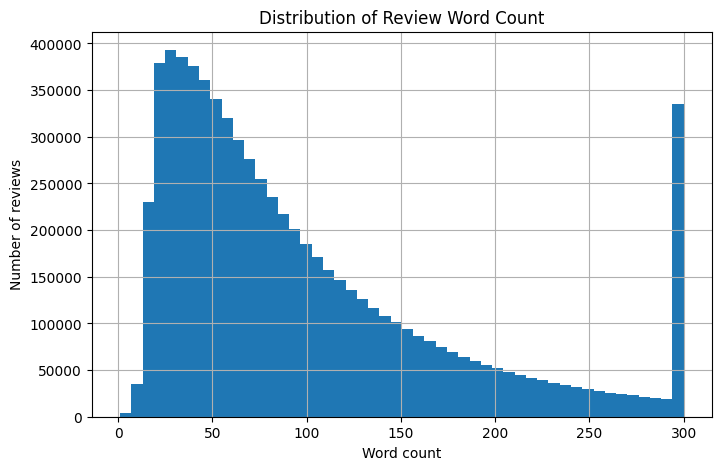

In [37]:
plt.figure(figsize=(8, 5))
df["review_word_count"].clip(upper=300).hist(bins=50)
plt.title("Distribution of Review Word Count")
plt.xlabel("Word count")
plt.ylabel("Number of reviews")
plt.show()

In [38]:
# ============================================================
# 3. Rating distribution
# ============================================================

rating_dist = (
    df["review_stars"]
    .value_counts(normalize=True)
    .sort_index()
    .reset_index()
)

rating_dist.columns = ["review_stars", "ratio"]
rating_dist

,review_stars,ratio
0,1.00,0.15
1,2.00,0.08
2,3.00,0.10
3,4.00,0.21
4,5.00,0.46


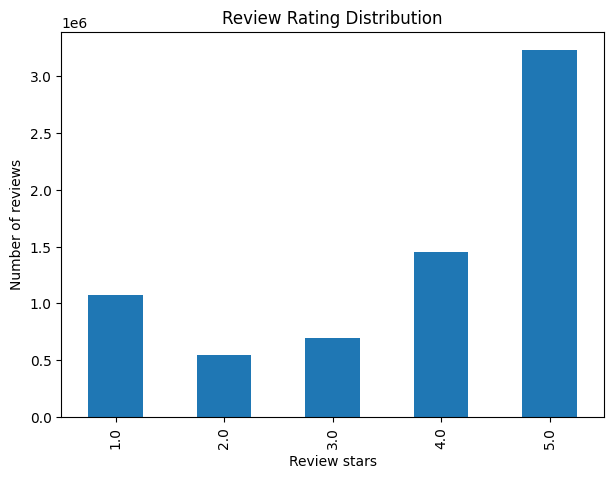

In [39]:
plt.figure(figsize=(7, 5))
df["review_stars"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Rating Distribution")
plt.xlabel("Review stars")
plt.ylabel("Number of reviews")
plt.show()

In [40]:
# ============================================================
# 4. Review length vs rating
# ============================================================
df["review_stars"] = df["review_stars"].astype("float32")
df["review_word_count"] = df["review_word_count"].astype("int32")

length_by_rating = (
    df.groupby("review_stars")["review_word_count"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

length_by_rating

,review_stars,count,mean,median,std
0,1.00,1069561,133.98,96.00,124.71
1,2.00,544240,134.34,101.00,115.14
2,3.00,691934,124.20,95.00,104.55
3,4.00,1452918,108.04,81.00,93.63
4,5.00,3231627,84.51,61.00,78.44


<Figure size 800x500 with 0 Axes>

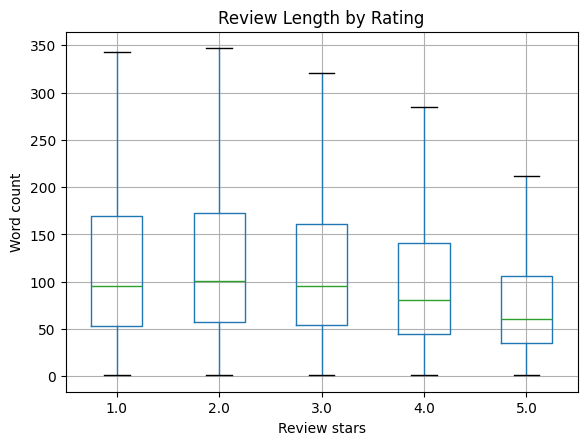

In [41]:
plt.figure(figsize=(8, 5))
df.boxplot(column="review_word_count", by="review_stars", showfliers=False)
plt.title("Review Length by Rating")
plt.suptitle("")
plt.xlabel("Review stars")
plt.ylabel("Word count")
plt.show()

In [42]:
# ============================================================
# 5. Create sentiment target
# ============================================================

df["target_sentiment"] = np.where(
    df["review_stars"] <= 2,
    "negative",
    np.where(df["review_stars"] == 3, "neutral", "positive")
)

df["target_sentiment"].value_counts(normalize=True)

target_sentiment
positive   0.67
negative   0.23
neutral    0.10
Name: proportion, dtype: float64

In [43]:
# ============================================================
# 6. TF-IDF keyword analysis by sentiment
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

df["review_stars"] = df["review_stars"].astype("float32")
df["review_word_count"] = df["review_word_count"].astype("int32")

sample_for_tfidf = df.sample(
    n=min(200_000, len(df)),
    random_state=42
).copy()

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=20
)

X_tfidf = vectorizer.fit_transform(sample_for_tfidf["review_text"])
terms = np.array(vectorizer.get_feature_names_out())


def top_tfidf_terms(label, top_n=25):
    # Convert pandas boolean Series to numpy array for scipy sparse indexing
    idx = (sample_for_tfidf["target_sentiment"] == label).to_numpy()

    # Calculate average TF-IDF score for the selected sentiment class
    mean_scores = np.asarray(X_tfidf[idx].mean(axis=0)).ravel()

    # Get top terms
    top_idx = np.argsort(mean_scores)[::-1][:top_n]

    return pd.DataFrame({
        "term": terms[top_idx],
        "score": mean_scores[top_idx]
    })


top_positive_terms = top_tfidf_terms("positive")
top_neutral_terms = top_tfidf_terms("neutral")
top_negative_terms = top_tfidf_terms("negative")

top_negative_terms

,term,score
0,food,0.03
1,service,0.03
2,just,0.02
3,place,0.02
4,time,0.02
5,like,0.02
6,told,0.02
7,order,0.02
8,said,0.02
9,don,0.02


In [44]:
top_positive_terms

,term,score
0,great,0.04
1,food,0.03
2,good,0.03
3,place,0.03
4,service,0.02
5,best,0.02
6,delicious,0.02
7,time,0.02
8,love,0.02
9,amazing,0.02


<Figure size 800x500 with 0 Axes>

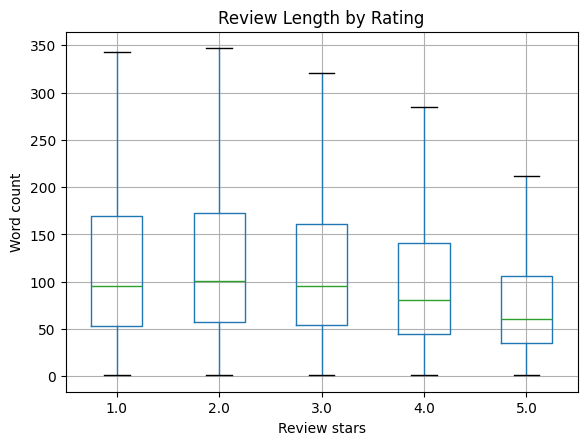

In [45]:
plt.figure(figsize=(8, 5))
df.boxplot(column="review_word_count", by="review_stars", showfliers=False)
plt.title("Review Length by Rating")
plt.suptitle("")
plt.xlabel("Review stars")
plt.ylabel("Word count")
plt.show()

In [46]:
# ============================================================
# 7. Category analysis
# ============================================================

category_df = df[
    ["business_id", "categories", "review_stars", "review_word_count", "target_sentiment"]
].dropna(subset=["categories"]).copy()

category_df["category"] = category_df["categories"].str.split(", ")
category_df = category_df.explode("category")

category_summary = (
    category_df
    .groupby("category")
    .agg(
        review_count=("review_stars", "count"),
        avg_rating=("review_stars", "mean"),
        avg_review_length=("review_word_count", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean())
    )
    .reset_index()
)

category_summary = category_summary[category_summary["review_count"] >= 1000]
category_summary.sort_values("review_count", ascending=False).head(20)

,category,review_count,avg_rating,avg_review_length,negative_ratio
1014,Restaurants,4724471,3.79,100.27,0.21
466,Food,1813593,3.89,97.48,0.18
806,Nightlife,1539757,3.79,105.96,0.20
104,Bars,1455553,3.79,105.42,0.20
33,American (Traditional),1011646,3.67,101.59,0.23
32,American (New),984540,3.84,108.44,0.19
165,Breakfast & Brunch,867430,3.88,97.74,0.18
1033,Sandwiches,691864,3.85,92.44,0.19
1045,Seafood,620247,3.85,101.21,0.19
419,Event Planning & Services,609553,3.69,117.15,0.24


In [47]:
category_summary.sort_values("negative_ratio", ascending=False).head(20)

,category,review_count,avg_rating,avg_review_length,negative_ratio
1176,Television Service Providers,4450,1.70,135.57,0.81
640,Internet Service Providers,8295,2.00,132.48,0.74
1231,University Housing,2811,2.29,180.60,0.64
966,Psychiatrists,1019,2.42,139.26,0.64
1220,Truck Rental,3747,2.38,133.45,0.63
962,Property Management,13129,2.46,158.89,0.62
1238,Utilities,2387,2.51,122.67,0.61
942,Post Offices,5517,2.41,106.41,0.60
1175,Telecommunications,5977,2.58,123.67,0.59
642,Investing,1522,2.55,128.27,0.58


In [48]:
# ============================================================
# 8. City-level analysis
# ============================================================

city_summary = (
    df.groupby(["city", "state"])
    .agg(
        review_count=("review_id", "count"),
        business_count=("business_id", "nunique"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean()),
        avg_review_length=("review_word_count", "mean")
    )
    .reset_index()
)

city_summary = city_summary[city_summary["review_count"] >= 1000]
city_summary.sort_values("review_count", ascending=False).head(20)

,city,state,review_count,business_count,avg_rating,negative_ratio,avg_review_length
901,Philadelphia,PA,967517,14567,3.79,0.20,112.64
792,New Orleans,LA,635329,6208,3.94,0.17,100.92
1203,Tampa,FL,454833,9048,3.75,0.23,105.27
777,Nashville,TN,451506,6968,3.82,0.21,103.04
1257,Tucson,AZ,404865,9249,3.70,0.25,104.19
533,Indianapolis,IN,361489,7540,3.82,0.20,109.41
962,Reno,NV,351518,5932,3.75,0.24,111.45
1043,Santa Barbara,CA,269630,3829,4.00,0.18,99.62
1025,Saint Louis,MO,253437,4827,3.81,0.20,111.19
94,Boise,ID,105366,2937,3.79,0.23,99.48


In [49]:
city_summary.sort_values("negative_ratio", ascending=False).head(20)

,city,state,review_count,business_count,avg_rating,negative_ratio,avg_review_length
192,Chester,PA,1914,49,2.64,0.52,153.81
1403,Wyncote,PA,1360,60,2.82,0.47,111.93
639,Lumberton,NJ,1101,62,3.02,0.46,100.62
755,Mt. Laurel,NJ,1249,32,2.97,0.44,118.14
119,Bridgeton,MO,4304,166,3.07,0.42,110.68
388,Flourtown,PA,1898,66,3.08,0.42,108.88
378,Fenton,MO,6519,288,3.11,0.42,110.33
496,Hazelwood,MO,2248,104,3.08,0.42,114.25
841,Oaks,PA,1756,43,3.05,0.41,113.00
1262,Turnersville,NJ,3194,130,3.21,0.40,114.65


In [50]:
# ============================================================
# 9. User behavior analysis
# ============================================================
df["user_review_count"] = df["user_review_count"].fillna(0).astype("float32")
df["review_stars"] = df["review_stars"].astype("float32")
df["review_word_count"] = df["review_word_count"].astype("int32")


df["user_experience_bucket"] = pd.cut(
    df["user_review_count"],
    bins=[0, 5, 20, 100, 500, np.inf],
    labels=["0-5", "6-20", "21-100", "101-500", "500+"]
)

user_behavior = (
    df.groupby("user_experience_bucket", observed=True)
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean()),
        avg_review_length=("review_word_count", "mean")
    )
    .reset_index()
)

user_behavior

,user_experience_bucket,review_count,avg_rating,negative_ratio,avg_review_length
0,0-5,1436369,3.43,0.37,92.90
1,6-20,1818497,3.76,0.26,88.97
2,21-100,2019109,3.84,0.20,100.11
3,101-500,1327779,3.90,0.13,130.69
4,500+,388438,3.87,0.10,158.33


<Figure size 800x500 with 0 Axes>

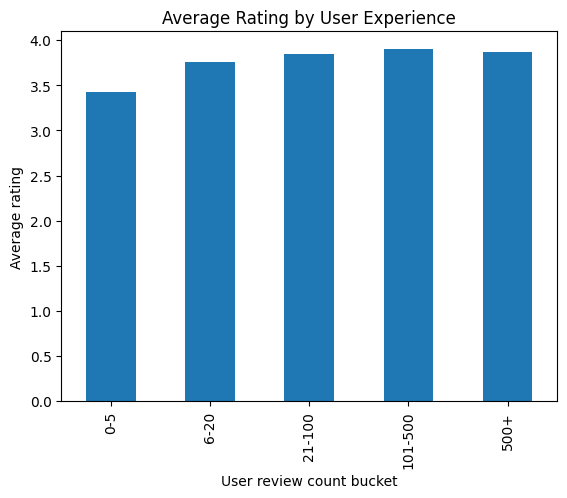

In [51]:
plt.figure(figsize=(8, 5))
user_behavior.plot(
    x="user_experience_bucket",
    y="avg_rating",
    kind="bar",
    legend=False
)
plt.title("Average Rating by User Experience")
plt.xlabel("User review count bucket")
plt.ylabel("Average rating")
plt.show()

In [52]:
# ============================================================
# 10. Business reputation gap
# ============================================================

df["rating_gap"] = df["review_stars"] - df["business_stars"]

rating_gap_summary = df["rating_gap"].describe()
rating_gap_summary

count   6,990,280.00
mean           -0.00
std             1.29
min            -4.00
25%            -1.00
50%             0.50
75%             1.00
max             4.00
Name: rating_gap, dtype: float64

In [53]:
extreme_negative_gap = (
    df.sort_values("rating_gap")
    [
        [
            "business_name",
            "city",
            "state",
            "business_stars",
            "review_stars",
            "rating_gap",
            "review_text"
        ]
    ]
    .head(10)
)

extreme_negative_gap

,business_name,city,state,business_stars,review_stars,rating_gap,review_text
3355290,Nikko's Dog Barrrrr,Saint Pete Beach,FL,5.00,1.00,-4.00,"Worst place ever...Tony is a fucking liar and the people in there worst humans on earth. (Expect for young lady and another dog owners we who helped me) My dog was nearly eaten by a very aggressive pit bull. Other people in the bar said it wasn't the 1st time...I can't go into details as it'll be a legal situation as of today. Just beware Tony pretends to care, but in the end in a fucking worthless liar. I just moved here and am just getting started to make sure he and others are held liable for their poor decisions and lack of actions.\n\nTony continues to duck me after he promised to help me the next AM. Do not go here to support this fool. BE CAREFUL if you have a small-med dog, they do not believe in them. I had my life threatened by a staff member or a regular during the trauma. I'll upload photos after legal actions of the bloodshed. I wish the worst upon Tony for his immoral lack of action & going against his word. Heartless POS."
437551,Savage Beauty Salon,New Orleans,LA,5.00,1.00,-4.00,"I have long hair. Jo talked me out of what I asked for, which was a finished-looking blunt cut. I had ""ragged"" face-framing layers, a cut that you can make look great when you blow dry it, but I wanted more finished ""blunt"" ends, which was the whole reason I came to a salon that had great reviews. I do not want to have to do anything but wash my hair to make it look great, and I explained that to her. She did one of those random layer cuts -- snip here, snip there. Sure, my hair looked great after she spent more than half of the appointment blowing it out, but I don't do that all of the time. After I washed it myself, I ended up with the same ragged ends that I came in with. I could have cut it myself. Also, when a salon owner cuts your hair, it used to be traditional that they did not expect a tip. But if you use a credit card here, you get the same screen you get in a taxi, with a minimum 20% tip as an option. Since Jo is the only person cutting at this salon, she is clearly the owner. Standing in front of her, I felt pressured to put a tip down. It was a waste of money. I would not go back."
4764574,Ackerman Jewelers,Tampa,FL,5.00,1.00,-4.00,"Really.., closed on Mondays now!!?? WTF??\nNot helpful Ackerman's.\nPlease reopen on Mondays."
772119,Chandler Men's Salon,Santa Barbara,CA,5.00,1.00,-4.00,"I decided to go to Chandler Men's Salon based on the Yelp reviews, and I have to say, my experience was far from the five stars everyone here seems to be ascribing to Chandler. \n\nTo be fair, my bad experience was not necessarily with the salon but rather the stylist. Right off the bat, I got a bad vibe from this woman. She was standoffish and seemed as if her mind was elsewhere. I should have left after shaking her hand, but I second guessed myself and stayed.\n\nAfter sitting in the chair, she asked me what I wanted done. Now, I have long hair for a guy (combed forward it reaches my chin) which I brush back into an attempted Bradley Cooper look. I told her I want to keep the majority of the length and basically just want it reshaped. She agreed, held up a chunk of hair with about two inches protruding beyond her fingertips and said, ""I'll take this much off."" I consented, took off my glasses and let her proceed.\n\nI'm fairly blind without my glasses, so I was basically unaware what was happening while she was cutting away. My head felt lighter, but I had no idea how much lighter until putting my glasses back on. When I did, boy, was I shocked. She had taken off all but three inches. More than half of my hair: gone. I basically look like a 19 year old fresh out of basic training.\n\nTruthfully, one of the worst experiences I have had at a salon. Her lack of ability to listen resulted in the loss of three months of growth and mockery from my girlfriend, peers, and coworkers. I will not be goin

In [54]:
# ============================================================
# 11. Review usefulness analysis
# ============================================================

df["is_useful_review"] = (df["review_useful"] > 0).astype(int)

usefulness_summary = (
    df.groupby("is_useful_review")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        avg_review_length=("review_word_count", "mean"),
        avg_user_review_count=("user_review_count", "mean"),
        avg_business_stars=("business_stars", "mean")
    )
    .reset_index()
)

usefulness_summary

,is_useful_review,review_count,avg_rating,avg_review_length,avg_user_review_count,avg_business_stars
0,0,3840496,3.88,81.79,66.92,3.78
1,1,3149784,3.59,132.80,193.23,3.72


<Figure size 800x500 with 0 Axes>

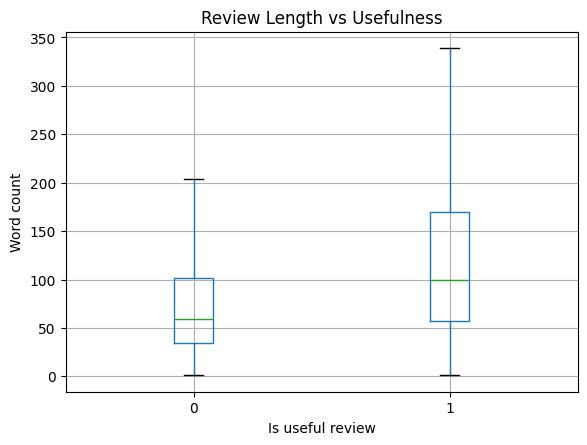

In [55]:
plt.figure(figsize=(8, 5))
df.boxplot(column="review_word_count", by="is_useful_review", showfliers=False)
plt.title("Review Length vs Usefulness")
plt.suptitle("")
plt.xlabel("Is useful review")
plt.ylabel("Word count")
plt.show()

In [56]:
# ============================================================
# 12. Temporal analysis
# ============================================================

df["review_year"] = df["review_date"].dt.year
df["review_month"] = df["review_date"].dt.to_period("M").astype(str)
df["review_weekday"] = df["review_date"].dt.day_name()

monthly_summary = (
    df.groupby("review_month")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean())
    )
    .reset_index()
)

monthly_summary.head()

,review_month,review_count,avg_rating,negative_ratio
0,2005-02,3,4.33,0.00
1,2005-03,74,3.65,0.18
2,2005-04,26,4.15,0.04
3,2005-05,108,4.08,0.07
4,2005-06,38,4.03,0.11


<Figure size 1200x500 with 0 Axes>

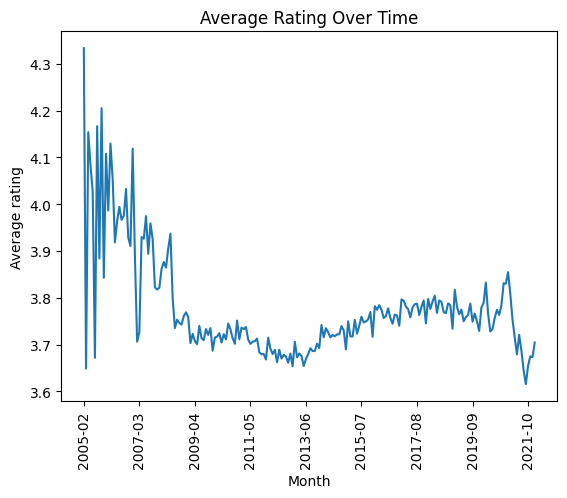

In [57]:
plt.figure(figsize=(12, 5))
monthly_summary.plot(x="review_month", y="avg_rating", legend=False)
plt.title("Average Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average rating")
plt.xticks(rotation=90)
plt.show()

In [58]:
weekday_summary = (
    df.groupby("review_weekday")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean())
    )
    .reset_index()
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_summary["review_weekday"] = pd.Categorical(
    weekday_summary["review_weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_summary.sort_values("review_weekday")

,review_weekday,review_count,avg_rating,negative_ratio
1,Monday,1030129,3.72,0.23
5,Tuesday,943417,3.75,0.23
6,Wednesday,945565,3.77,0.22
4,Thursday,917648,3.78,0.22
0,Friday,942156,3.77,0.23
2,Saturday,1065456,3.75,0.24
3,Sunday,1145909,3.71,0.24


In [59]:
# ============================================================
# 13. Do tips add useful context?
# ============================================================

df["has_tips"] = df["tip_count"].fillna(0) > 0

tips_effect = (
    df.groupby("has_tips")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("review_stars", "mean"),
        negative_ratio=("target_sentiment", lambda x: (x == "negative").mean()),
        avg_review_length=("review_word_count", "mean")
    )
    .reset_index()
)

tips_effect

,has_tips,review_count,avg_rating,negative_ratio,avg_review_length
0,False,492444,3.59,0.32,114.41
1,True,6497836,3.76,0.22,104.05


In [60]:
# ============================================================
# 15. Save modeling dataset
# ============================================================

model_dataset = df[
    [
        "review_id",
        "business_id",
        "user_id",
        "review_date",
        "review_stars",
        "target_sentiment",
        "review_text",
        "business_name",
        "city",
        "state",
        "categories",
        "business_stars",
        "business_review_count",
        "user_review_count",
        "user_average_stars",
        "review_word_count",
        "review_useful",
        "tip_count",
        "sample_tips",
        "rating_gap"
    ]
].copy()

model_dataset.shape

(6990280, 20)

In [62]:
df.columns

Index(['review_id', 'user_id', 'business_id', 'review_stars', 'review_useful',
       'review_funny', 'review_cool', 'review_text', 'review_date',
       'business_name', 'city', 'state', 'latitude', 'longitude',
       'business_stars', 'business_review_count', 'is_open', 'attributes',
       'categories', 'user_name', 'user_review_count', 'yelping_since',
       'user_average_stars', 'useful', 'funny', 'cool', 'fans', 'elite',
       'tip_count', 'sample_tips', 'avg_tip_compliment', 'latest_tip_date',
       'review_char_count', 'review_word_count', 'target_sentiment',
       'user_experience_bucket', 'rating_gap', 'is_useful_review',
       'review_year', 'review_month', 'review_weekday', 'has_tips'],
      dtype='object')

In [63]:
model_dataset.columns

Index(['review_id', 'business_id', 'user_id', 'review_date', 'review_stars',
       'target_sentiment', 'review_text', 'business_name', 'city', 'state',
       'categories', 'business_stars', 'business_review_count',
       'user_review_count', 'user_average_stars', 'review_word_count',
       'review_useful', 'tip_count', 'sample_tips', 'rating_gap'],
      dtype='object')